In [1]:
import pandas as pd
from pathlib import Path

# Load Training Data

In [2]:
# load training data
DATA_DIR = "split_data"           # same folder frozen_train.ipynb reads from
SPLIT_DIR = "frozen-split_data"   # where frozen_train.ipynb wrote the split map
OUTPUT_DIR = Path("task3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

contracts = pd.read_parquet(f"{DATA_DIR}/contracts.parquet")
documents = pd.read_parquet(f"{DATA_DIR}/documents.parquet")
categories = pd.read_parquet(f"{DATA_DIR}/categories.parquet")
annotation_sets = pd.read_parquet(f"{DATA_DIR}/annotation_sets.parquet")
spans = pd.read_parquet(f"{DATA_DIR}/spans.parquet")
split_map = pd.read_parquet(f"{SPLIT_DIR}/frozen-split.parquet")

documents = documents.merge(split_map, on="context_group_id", how="left")

# each document should have a split label
unmatched = documents["split"].isna().sum()
print(f"documents with NO split label (should be 0): {unmatched}")

train_documents = documents[documents["split"] == "train"].copy()
train_contract_ids = set(train_documents["contract_id"])

train_contracts = contracts[contracts["contract_id"].isin(train_contract_ids)].copy()
train_annotation_sets = annotation_sets[annotation_sets["contract_id"].isin(train_contract_ids)].copy()
train_spans = spans[spans["annotation_set_id"].isin(train_annotation_sets["annotation_set_id"])].copy()

print(f"train contracts:{len(train_contracts)}")
print(f"train documents:{len(train_documents)}")
print(f"train annotation sets:{len(train_annotation_sets)}")
print(f"train spans:{len(train_spans)}")

# rename references
contracts = train_contracts
documents = train_documents
categories = categories
annotation_sets = train_annotation_sets
spans = train_spans
# TODO: save all this in a parquet

documents with NO split label (should be 0): 0
train contracts:325
train documents:325
train annotation sets:13325
train spans:8964


# Finding Positive Examples
Using training data only, report the number of positive Contracts, distinct context groups, and annotated spans for each category.

In [3]:
# category names from task 5... TODO: verify these categories
final_cat_names = [
    "Governing Law",
    "Renewal Term",
    "Revenue/Profit Sharing",
    "Cap On Liability",
    "Uncapped Liability",
    "Termination For Convenience",
    "Anti-Assignment",
    "Audit Rights",
    "License Grant",
    "Exclusivity"
]
final_ids = categories.loc[categories.category_name.isin(final_cat_names), 'category_id']

# find the annotated sets that are related to each of the final categories
condition = annotation_sets.category_id.isin(final_ids) & ~annotation_sets.is_impossible
positive_sets = annotation_sets[condition]
positive_sets

,annotation_set_id,contract_id,category_id,is_impossible
3,contract_0001__anti_assignment,contract_0001,anti_assignment,False
11,contract_0001__exclusivity,contract_0001,exclusivity,False
13,contract_0001__governing_law,contract_0001,governing_law,False
18,contract_0001__license_grant,contract_0001,license_grant,False
31,contract_0001__renewal_term,contract_0001,renewal_term,False
...,...,...,...,...
16691,contract_0408__audit_rights,contract_0408,audit_rights,False
16698,contract_0408__exclusivity,contract_0408,exclusivity,False
16700,contract_0408__governing_law,contract_0408,governing_law,False
16705,contract_0408__license_grant,contract_0408,license_grant,False


In [4]:
# contracts that contain the positive sets
positive_contracts = positive_sets.merge(documents[['document_id','contract_id', 'context_group_id']], on="contract_id")

summary = positive_contracts.groupby('category_id').agg(
    num_positive_contracts=('contract_id', 'nunique'),
    num_positive_context_groups=('context_group_id', 'nunique'),
)

# num annotated spans for each category
positive_spans = spans.merge(positive_sets[["annotation_set_id", "category_id"]], on="annotation_set_id")
span_count = positive_spans.groupby('category_id').size().reset_index(name="num_positive_span")

summary = summary.merge(span_count, on="category_id")

**Final Summary**
The number of positive contracts, distinct context groups, and annotated spans for each category

In [5]:
summary

,category_id,num_positive_contracts,num_positive_context_groups,num_positive_span
0,anti_assignment,235,235,408
1,audit_rights,139,139,417
2,cap_on_liability,184,184,458
3,exclusivity,117,117,274
4,governing_law,274,273,290
5,license_grant,163,163,530
6,renewal_term,120,120,144
7,revenue_profit_sharing,103,103,269
8,termination_for_convenience,123,122,165
9,uncapped_liability,78,78,123


 Confirm that each category has at least 20 positive Contracts and 20 positive context groups. Document and justify any exception.

Each category has sufficient examples of positive contracts and context groups.

In [6]:
(summary["num_positive_contracts"] < 20).any() | (summary["num_positive_context_groups"] < 20).any()

np.False_

# Category Co-Occurrence
Show how often related categories appear together.

In [7]:
presence = positive_contracts[["contract_id", "category_id"]].drop_duplicates()
# contract x category 0/1 matrix, keeping all 41 category columns even if some have zero train support
presence_matrix = (
    presence.assign(present=1)
    .pivot_table(index="contract_id", columns="category_id", values="present", fill_value=0)
    .reindex(columns=final_ids, fill_value=0)
)

# cooccurrence[i, j] = number of contracts where category i AND category j both appear
cooccurrence = presence_matrix.T.dot(presence_matrix)
cooccurrence

category_id,renewal_term,governing_law,exclusivity,termination_for_convenience,anti_assignment,revenue_profit_sharing,license_grant,audit_rights,uncapped_liability,cap_on_liability
category_id,,,,,,,,,,
renewal_term,120.0,114.0,60.0,52.0,107.0,55.0,77.0,75.0,42.0,91.0
governing_law,114.0,274.0,113.0,117.0,229.0,94.0,155.0,137.0,77.0,180.0
exclusivity,60.0,113.0,117.0,40.0,102.0,58.0,91.0,70.0,38.0,83.0
termination_for_convenience,52.0,117.0,40.0,123.0,104.0,40.0,68.0,67.0,33.0,90.0
anti_assignment,107.0,229.0,102.0,104.0,235.0,81.0,146.0,129.0,77.0,164.0
revenue_profit_sharing,55.0,94.0,58.0,40.0,81.0,103.0,72.0,67.0,28.0,70.0
license_grant,77.0,155.0,91.0,68.0,146.0,72.0,163.0,94.0,64.0,124.0
audit_rights,75.0,137.0,70.0,67.0,129.0,67.0,94.0,139.0,55.0,113.0
uncapped_liability,42.0,77.0,38.0,33.0,77.0,28.0,64.0,55.0,78.0,78.0


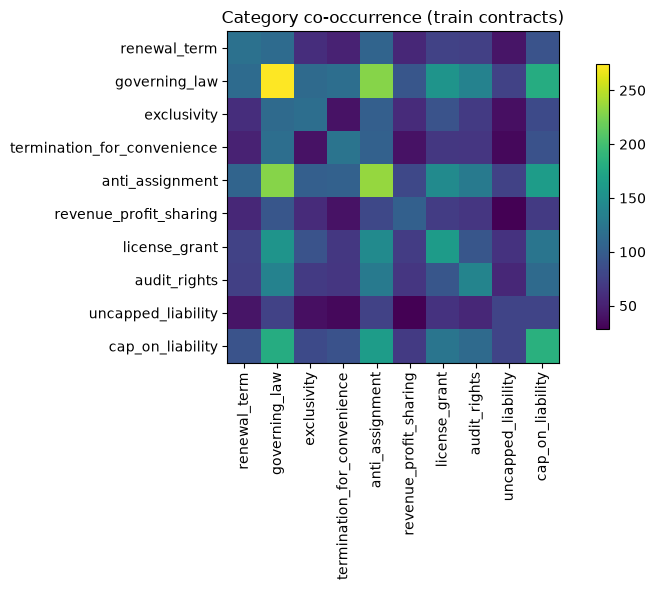

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(cooccurrence.values, cmap="viridis")
ax.set_xticks(range(len(cooccurrence.columns)))
ax.set_xticklabels(cooccurrence.columns, rotation=90, fontsize=10)
ax.set_yticks(range(len(cooccurrence.index)))
ax.set_yticklabels(cooccurrence.index, fontsize=10)
ax.set_title("Category co-occurrence (train contracts)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Hard Examples
 Provide five representative positive source-text excerpts and five realistic hard-negative source-text excerpts from the training Contracts for each category. For every excerpt, record its source Contract and text location. For each positive excerpt, also identify the annotated Span.

## Positive Examples

In [9]:
pos_span_w_contract = positive_spans.merge(
    positive_sets[['annotation_set_id', 'contract_id']],
    on='annotation_set_id'
)

# 5 random examples per group, seeded so "randomness" persists
positive_examples = pos_span_w_contract[["contract_id", "annotation_set_id", "category_id", "answer_text", "answer_start", "answer_end"]].groupby("category_id").sample(n=5, random_state=42)

positive_examples

,contract_id,annotation_set_id,category_id,answer_text,answer_start,answer_end
506,contract_0073,contract_0073__anti_assignment,anti_assignment,Consequently either this Agreement or any of t...,87997,88434
1675,contract_0214,contract_0214__anti_assignment,anti_assignment,"Either Party may, without consent of the other...",243853,244338
1947,contract_0249,contract_0249__anti_assignment,anti_assignment,Neither this Agreement nor any rights or oblig...,85146,85673
269,contract_0042,contract_0042__anti_assignment,anti_assignment,This Agreement may not be assigned by Broker D...,25119,25275
336,contract_0056,contract_0056__anti_assignment,anti_assignment,"The Distributor shall not sub-license, transfe...",12823,12960
1295,contract_0177,contract_0177__audit_rights,audit_rights,The Auditing Party may cause the Auditor to pe...,50688,51060
940,contract_0137,contract_0137__audit_rights,audit_rights,Franchisee shall fully cooperate with Pretzel ...,147028,147187
2724,contract_0356,contract_0356__audit_rights,audit_rights,"Premier, shall have the right, directly or thr...",16698,17052
2440,contract_0318,contract_0318__audit_rights,audit_rights,"SHPS shall have the right, upon reasonable pri...",6856,7078
1121,contract_0160,contract_0160__audit_rights,audit_rights,In addition to any inspection rights granted u...,44670,44887


In [10]:
display_samples = positive_examples.sample(n=5, random_state=42)
for _, sample in display_samples.iterrows():
    print(f"CATEGORY ID: {sample['category_id']}")
    print(f"CONTRACT ID: {sample['contract_id']}")
    print(f"EXAMPLE: {sample['answer_text']}\n")

CATEGORY ID: cap_on_liability
CONTRACT ID: contract_0208
EXAMPLE: IBM will give Customer a credit equal to the amount Customer paid IBM for the applicable Materials or for use of the applicable Base Components up to a maximum of twelve (12) months of applicable charges.

CATEGORY ID: revenue_profit_sharing
CONTRACT ID: contract_0360
EXAMPLE: In consideration of the license of Liquidmetal Technical Information and the Licensed Equipment granted by Liquidmetal, Eutectix agrees to pay Liquidmetal a cash royalty based on a percentage of the invoice price of any Licensed Products (but not including Liquidmetal Products) sold by Eutectix or its permitted sublicensees and for which payment was actually received by Eutectix.

CATEGORY ID: renewal_term
CONTRACT ID: contract_0167
EXAMPLE: Within ninety (90) days of our receipt of your notice to renew, we will furnish you with written notice of:  (i) reasons which could cause us not to grant a renewal to you including but not limited to any defic

## Negative Examples

In [11]:
# find the annotated sets that are related to each of the final categories
condition = annotation_sets.category_id.isin(final_ids) & annotation_sets.is_impossible
negative_sets = annotation_sets[condition]
negative_sets

,annotation_set_id,contract_id,category_id,is_impossible
4,contract_0001__audit_rights,contract_0001,audit_rights,True
5,contract_0001__cap_on_liability,contract_0001,cap_on_liability,True
32,contract_0001__revenue_profit_sharing,contract_0001,revenue_profit_sharing,True
35,contract_0001__termination_for_convenience,contract_0001,termination_for_convenience,True
37,contract_0001__uncapped_liability,contract_0001,uncapped_liability,True
...,...,...,...,...
16683,contract_0407__uncapped_liability,contract_0407,uncapped_liability,True
16692,contract_0408__cap_on_liability,contract_0408,cap_on_liability,True
16718,contract_0408__renewal_term,contract_0408,renewal_term,True
16722,contract_0408__termination_for_convenience,contract_0408,termination_for_convenience,True


In [12]:
all_spans_w_category = spans.merge(annotation_sets[["annotation_set_id", "category_id", "contract_id"]], on="annotation_set_id")
negative_spans = all_spans_w_category[~all_spans_w_category['span_id'].isin(positive_spans['span_id'])]

Confirm that there are no duplicates (both positive and negative examples)

In [13]:
negative_spans.shape[0] + positive_spans.shape[0] == spans.shape[0]

True

In [14]:
# 5 random examples per group, seeded so "randomness" persists
negative_examples = negative_spans[["contract_id", "annotation_set_id", "category_id", "answer_text", "answer_start", "answer_end"]].groupby("category_id").sample(n=5, random_state=42)
negative_examples

,contract_id,annotation_set_id,category_id,answer_text,answer_start,answer_end
241,contract_0011,contract_0011__affiliate_license_licensee,affiliate_license_licensee,Subject to the terms and conditions of this Ag...,18678,19342
7011,contract_0317,contract_0317__affiliate_license_licensee,affiliate_license_licensee,Any rights or license granted under this Artic...,27829,28217
2076,contract_0099,contract_0099__affiliate_license_licensee,affiliate_license_licensee,The supply of the Miltenyi Products hereunder ...,22585,23532
237,contract_0011,contract_0011__affiliate_license_licensee,affiliate_license_licensee,"The licenses granted in Sections 4.01(a), (b) ...",26912,27409
3925,contract_0182,contract_0182__affiliate_license_licensee,affiliate_license_licensee,Distributor hereby grants Zogenix an irrevocab...,105454,105738
...,...,...,...,...,...,...
2977,contract_0142,contract_0142__warranty_duration,warranty_duration,Although Vendor intends to provide a six-month...,29202,29387
1190,contract_0058,contract_0058__warranty_duration,warranty_duration,E.piphany further warrants that its Maintenanc...,9507,9729
1661,contract_0077,contract_0077__warranty_duration,warranty_duration,"For each new Authorized Location, upon written...",5853,6197
790,contract_0038,contract_0038__warranty_duration,warranty_duration,"Upon Manufacturer's request, Subcontractor wil...",15838,16148


## Analysis

In [15]:
try:
    task6_bundles = pd.read_csv(Path("task6_outputs") / "proposed_bundles.csv")
    bundle_partner = dict(zip(task6_bundles["category_a"], task6_bundles["category_b"]))
    bundle_partner.update(dict(zip(task6_bundles["category_b"], task6_bundles["category_a"])))
    print("loaded bundle pairing from task6_outputs/proposed_bundles.csv")
except FileNotFoundError:
    bundle_partner = {
        "Cap On Liability": "Uncapped Liability", "Uncapped Liability": "Cap On Liability",
        "License Grant": "Exclusivity", "Exclusivity": "License Grant",
        "Renewal Term": "Termination For Convenience", "Termination For Convenience": "Renewal Term",
        "Revenue/Profit Sharing": "Audit Rights", "Audit Rights": "Revenue/Profit Sharing",
        "Governing Law": "Anti-Assignment", "Anti-Assignment": "Governing Law",
    }
    print("task6_outputs/proposed_bundles.csv not found -- using Task #6's draft pairing (update once finalized)")

loaded bundle pairing from task6_outputs/proposed_bundles.csv


In [16]:
# id_to_name / name_to_id_map, built from the real categories table (not reconstructed by
# hand) so they match the real category_id values exactly, including "Anti-Assignment"
id_to_name = dict(zip(categories.category_id, categories.category_name))
name_to_id_map = {v: k for k, v in id_to_name.items()}

span_counts = (
    positive_spans.merge(positive_sets[["annotation_set_id", "contract_id"]], on="annotation_set_id")
    .groupby(["category_id", "contract_id"])
    .size()
    .reset_index(name="span_count")
)
span_counts.head()

,category_id,contract_id,span_count
0,anti_assignment,contract_0001,2
1,anti_assignment,contract_0002,1
2,anti_assignment,contract_0004,1
3,anti_assignment,contract_0005,2
4,anti_assignment,contract_0008,1


In [17]:
# real annotated spans, already restricted to the final 10 categories (positive_spans),
# with contract_id attached (pos_span_w_contract, built in the Positive Examples section above)
candidate_pool = pos_span_w_contract

def hard_negatives_for(target_name, n=5, seed=42):
    target_id = name_to_id_map[target_name]
    pool = candidate_pool[candidate_pool["category_id"] != target_id]

    picks = []
    partner_name = bundle_partner.get(target_name)
    partner_id = name_to_id_map.get(partner_name) if partner_name else None
    if partner_id is not None:
        partner_pool = pool[pool["category_id"] == partner_id]
        n_partner = min(3, len(partner_pool))
        if n_partner:
            picks.append(partner_pool.sample(n=n_partner, random_state=seed))

    chosen_so_far = pd.concat(picks) if picks else pool.iloc[0:0]
    remaining = n - len(chosen_so_far)
    if remaining > 0:
        rest_pool = pool[~pool.index.isin(chosen_so_far.index)]
        picks.append(rest_pool.sample(n=min(remaining, len(rest_pool)), random_state=seed))

    result = pd.concat(picks).reset_index(drop=True)
    result["target_category"] = target_name
    result["negative_source_category"] = result["category_id"].map(id_to_name)
    return result

hard_negative_examples = pd.concat(
    [hard_negatives_for(name) for name in final_cat_names],
    ignore_index=True,
)
hard_negative_examples

,span_id,annotation_set_id,source_qa_id,answer_text,answer_start,answer_end,category_id,contract_id,target_category,negative_source_category
0,contract_0073__anti_assignment__span_001,contract_0073__anti_assignment,AzulSa_20170303_F-1A_EX-10.3_9943903_EX-10.3_M...,Consequently either this Agreement or any of t...,87997,88434,anti_assignment,contract_0073,Governing Law,Anti-Assignment
1,contract_0214__anti_assignment__span_006,contract_0214__anti_assignment,RevolutionMedicinesInc_20200117_S-1_EX-10.1_11...,"Either Party may, without consent of the other...",243853,244338,anti_assignment,contract_0214,Governing Law,Anti-Assignment
2,contract_0249__anti_assignment__span_001,contract_0249__anti_assignment,EhaveInc_20190515_20-F_EX-4.44_11678816_EX-4.4...,Neither this Agreement nor any rights or oblig...,85146,85673,anti_assignment,contract_0249,Governing Law,Anti-Assignment
3,contract_0295__anti_assignment__span_000,contract_0295__anti_assignment,BEYONDCOMCORP_08_03_2000-EX-10.2-CO-HOSTING AG...,Neither party may assign this Agreement withou...,28052,28334,anti_assignment,contract_0295,Governing Law,Anti-Assignment
4,contract_0407__license_grant__span_006,contract_0407__license_grant,KINGPHARMACEUTICALSINC_08_09_2006-EX-10.1-PROM...,Depomed hereby grants to King a non-assignable...,63634,63982,license_grant,contract_0407,Governing Law,License Grant
5,contract_0306__termination_for_convenience__sp...,contract_0306__termination_for_convenience,MANAKOASERVICESCORP_11_21_2007-EX-7.5-STRATEGI...,Either party may terminate this Agreement at a...,5872,5954,termination_for_convenience,contract_0306,Renewal Term,Termination For Convenience
6,contract_0266__termination_for_convenience__sp...,contract_0266__termination_for_convenience,"IPAYMENT,INC_05_14_2007-EX-10.1-SPONSORSHIP AG...",ISO may terminate this Agreement prior to its ...,65829,65946,termination_for_convenience,contract_0266,Renewal Term,Termination For Convenience
7,contract_0293__termination_for_convenience__sp...,contract_0293__termination_for_convenience,EmeraldHealthBioceuticalsInc_20200218_1-A_EX1A...,"EHS or EHN, on the one hand, and Dr. Murray, o...",7296,7461,termination_for_convenience,contract_0293,Renewal Term,Termination For Convenience
8,contract_0187__cap_on_liability__span_015,contract_0187__cap_on_liability,CHANGEPOINTCORP_03_08_2000-EX-10.6-LICENSE AND...,"ACTION FIRST ARISING, EVEN IF IT IS A CONTINUO...",55450,55700,cap_on_liability,contract_0187,Renewal Term,Cap On Liability
9,contract_0324__exclusivity__span_001,contract_0324__exclusivity,GluMobileInc_20070319_S-1A_EX-10.09_436630_EX-...,Licensee shall have the non-exclusive right an...,4341,4672,exclusivity,contract_0324,Renewal Term,Exclusivity


In [18]:
counts = hard_negative_examples.groupby("target_category").size()
checks = []
if not (counts == 5).all():
    checks.append(f"expected 5 hard negatives per category, got: {dict(counts[counts != 5])}")
if (hard_negative_examples["negative_source_category"] == hard_negative_examples["target_category"]).any():
    checks.append("a hard negative was drawn from its own target category")
if set(hard_negative_examples["target_category"]) != set(final_cat_names):
    checks.append("not every final-10 category got hard negatives")

if checks:
    print("FAILED:")
    for c in checks:
        print(f"  - {c}")
else:
    print("PASSED -- 5 hard negatives per category, all drawn from a different final-10 category")

PASSED -- 5 hard negatives per category, all drawn from a different final-10 category


In [19]:
hard_negative_examples.to_csv(OUTPUT_DIR / "hard_negative_examples.csv", index=False)
hard_negative_examples[["target_category", "negative_source_category", "contract_id", "answer_text"]].groupby("target_category").head(2)

,target_category,negative_source_category,contract_id,answer_text
0,Governing Law,Anti-Assignment,contract_0073,Consequently either this Agreement or any of t...
1,Governing Law,Anti-Assignment,contract_0214,"Either Party may, without consent of the other..."
5,Renewal Term,Termination For Convenience,contract_0306,Either party may terminate this Agreement at a...
6,Renewal Term,Termination For Convenience,contract_0266,ISO may terminate this Agreement prior to its ...
10,Revenue/Profit Sharing,Audit Rights,contract_0147,This right to audit shall remain in effect thr...
11,Revenue/Profit Sharing,Audit Rights,contract_0387,We have the right to inspect the proposed supp...
15,Cap On Liability,Uncapped Liability,contract_0066,The provisions of Section 9.1 and Section 9.2 ...
16,Cap On Liability,Uncapped Liability,contract_0154,THE LIMITATIONS ON LIABILITY FOR DAMAGES SET F...
20,Uncapped Liability,Cap On Liability,contract_0272,THE PROVIDER SHALL NOT BE LIABLE FOR ANY INCID...
21,Uncapped Liability,Cap On Liability,contract_0040,This includes in particular the liability excl...


In [20]:
# category_descriptions.csv has the official CUAD text (name/description/answer format/group);
# note it's case-inconsistent with our final_cat_names ("Cap on Liability" vs "Cap On Liability"),
# so match case-insensitively rather than on exact string equality
desc_by_name = {}
try:
    cat_desc = pd.read_csv("../data/cuad/category_descriptions.csv", encoding="utf-8-sig")
    cat_desc["name_clean"] = cat_desc["Category (incl. context and answer)"].str.replace("Category: ", "", regex=False)
    cat_desc["description_clean"] = cat_desc["Description"].str.replace("Description: ", "", regex=False)
    cat_desc["group_clean"] = cat_desc["Group"].str.replace("Group: ", "", regex=False)
    desc_by_name = {
        row["name_clean"].strip().lower(): {"description": row["description_clean"], "cuad_group": row["group_clean"]}
        for _, row in cat_desc.iterrows()
    }
    print(f"loaded {len(desc_by_name)} category descriptions from category_descriptions.csv")
except FileNotFoundError:
    print("category_descriptions.csv not found in the working directory -- evidence pack will skip descriptions")

loaded 41 category descriptions from category_descriptions.csv


# Category Concentration

For each of the final 10 categories: how many *different* contracts is the positive signal
actually coming from? A category with hundreds of spans that are mostly from a handful of
contracts is a lot thinner than the raw span count suggests.

In [21]:
def concentration_stats(group):
    total = group["span_count"].sum()
    sorted_counts = group["span_count"].sort_values(ascending=False).to_numpy()
    shares = sorted_counts / total
    return pd.Series({
        "num_contracts": len(group),
        "total_spans": int(total),
        "spans_per_contract": total / len(group),
        "top1_contract_share": shares[0],
        "top3_contract_share": shares[:3].sum(),
        "hhi": (shares ** 2).sum(),
    })

CONCENTRATION_FLAG_THRESHOLD = 0.25

concentration = span_counts.groupby("category_id").apply(concentration_stats).reset_index()
concentration["category_name"] = concentration["category_id"].map(id_to_name)
concentration["flag_single_contract_heavy"] = concentration["top1_contract_share"] > CONCENTRATION_FLAG_THRESHOLD
concentration = concentration.sort_values("top1_contract_share", ascending=False).reset_index(drop=True)

concentration.to_csv(OUTPUT_DIR / "category_concentration.csv", index=False)
concentration

,category_id,num_contracts,total_spans,spans_per_contract,top1_contract_share,top3_contract_share,hhi,category_name,flag_single_contract_heavy
0,exclusivity,117.0,274.0,2.341880,0.043796,0.098540,0.013453,Exclusivity,False
1,revenue_profit_sharing,103.0,269.0,2.611650,0.040892,0.100372,0.015879,Revenue/Profit Sharing,False
2,uncapped_liability,78.0,123.0,1.576923,0.040650,0.113821,0.017252,Uncapped Liability,False
3,audit_rights,139.0,417.0,3.000000,0.038369,0.100719,0.013555,Audit Rights,False
4,cap_on_liability,184.0,458.0,2.489130,0.034934,0.072052,0.009134,Cap On Liability,False
5,renewal_term,120.0,144.0,1.200000,0.034722,0.076389,0.010127,Renewal Term,False
6,license_grant,163.0,530.0,3.251534,0.030189,0.079245,0.010858,License Grant,False
7,termination_for_convenience,123.0,165.0,1.341463,0.024242,0.066667,0.009881,Termination For Convenience,False
8,anti_assignment,235.0,408.0,1.736170,0.017157,0.049020,0.005923,Anti-Assignment,False
9,governing_law,274.0,290.0,1.058394,0.006897,0.020690,0.003829,Governing Law,False


In [22]:
import json

category_evidence = {}
summary_rows = []

for name in final_cat_names:
    cid = name_to_id_map[name]
    stats_row = summary[summary["category_id"] == cid].iloc[0]
    conc_row = concentration[concentration["category_id"] == cid].iloc[0]
    desc = desc_by_name.get(name.strip().lower(), {})

    # top 3 categories this one co-occurs with most, from the real cooccurrence matrix above
    co_series = cooccurrence[cid].drop(index=cid).sort_values(ascending=False)
    top_related = [
        {"category": id_to_name[other_id], "cooccurrence_count": int(count)}
        for other_id, count in co_series.head(3).items()
    ]

    pos_examples = positive_examples.loc[
        positive_examples["category_id"] == cid,
        ["contract_id", "answer_text", "answer_start", "answer_end"],
    ].to_dict(orient="records")

    neg_examples = hard_negative_examples.loc[
        hard_negative_examples["target_category"] == name,
        ["contract_id", "negative_source_category", "answer_text", "answer_start", "answer_end"],
    ].to_dict(orient="records")

    category_evidence[name] = {
        "category_id": cid,
        "cuad_group": desc.get("cuad_group"),
        "description": desc.get("description"),
        "statistics": {
            "num_positive_contracts": int(stats_row["num_positive_contracts"]),
            "num_positive_context_groups": int(stats_row["num_positive_context_groups"]),
            "num_positive_spans": int(stats_row["num_positive_span"]),
            "spans_per_contract": round(float(conc_row["spans_per_contract"]), 2),
            "top1_contract_share": round(float(conc_row["top1_contract_share"]), 3),
            "flag_single_contract_heavy": bool(conc_row["flag_single_contract_heavy"]),
        },
        "related_categories": top_related,
        "positive_examples": pos_examples,
        "hard_negative_examples": neg_examples,
    }

    summary_rows.append({
        "category_name": name,
        "cuad_group": desc.get("cuad_group"),
        "num_positive_contracts": int(stats_row["num_positive_contracts"]),
        "num_positive_spans": int(stats_row["num_positive_span"]),
        "spans_per_contract": round(float(conc_row["spans_per_contract"]), 2),
        "top1_contract_share": round(float(conc_row["top1_contract_share"]), 3),
        "flag_single_contract_heavy": bool(conc_row["flag_single_contract_heavy"]),
        "top_related_category": top_related[0]["category"] if top_related else None,
        "top_related_cooccurrence": top_related[0]["cooccurrence_count"] if top_related else None,
    })

with open(OUTPUT_DIR / "category_evidence.json", "w") as f:
    json.dump(category_evidence, f, indent=2)

evidence_summary = pd.DataFrame(summary_rows)
evidence_summary.to_csv(OUTPUT_DIR / "category_evidence_summary.csv", index=False)

evidence_summary

,category_name,cuad_group,num_positive_contracts,num_positive_spans,spans_per_contract,top1_contract_share,flag_single_contract_heavy,top_related_category,top_related_cooccurrence
0,Governing Law,-,274,290,1.06,0.007,False,Anti-Assignment,229
1,Renewal Term,1,120,144,1.20,0.035,False,Governing Law,114
2,Revenue/Profit Sharing,-,103,269,2.61,0.041,False,Governing Law,94
3,Cap On Liability,6,184,458,2.49,0.035,False,Governing Law,180
4,Uncapped Liability,6,78,123,1.58,0.041,False,Cap On Liability,78
5,Termination For Convenience,-,123,165,1.34,0.024,False,Governing Law,117
6,Anti-Assignment,3,235,408,1.74,0.017,False,Governing Law,229
7,Audit Rights,5,139,417,3.00,0.038,False,Governing Law,137
8,License Grant,4,163,530,3.25,0.030,False,Governing Law,155
9,Exclusivity,2,117,274,2.34,0.044,False,Governing Law,113


In [23]:
checks = []
if len(category_evidence) != 10:
    checks.append(f"expected 10 categories in the evidence pack, got {len(category_evidence)}")
for name, entry in category_evidence.items():
    if len(entry["positive_examples"]) != 5:
        checks.append(f"{name}: expected 5 positive examples, got {len(entry['positive_examples'])}")
    if len(entry["hard_negative_examples"]) != 5:
        checks.append(f"{name}: expected 5 hard negatives, got {len(entry['hard_negative_examples'])}")
    if entry["description"] is None:
        checks.append(f"{name}: no CUAD description matched -- check category_descriptions.csv")

if checks:
    print("FAILED:")
    for c in checks:
        print(f"  - {c}")
else:
    print("PASSED -- all 10 categories have a description, statistics, related categories, 5 positive examples, and 5 hard negatives")

PASSED -- all 10 categories have a description, statistics, related categories, 5 positive examples, and 5 hard negatives
